[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Extra/X1-FeatureSelection.ipynb)

# X1 — Choosing Features When Most of Them Are Useless

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Extra material — optional: not covered in the lectures, and not examinable**

**When to read it:** any time after Class 5. It uses cross-validation and pipelines (`02C`), the lasso (`03C` §4), feature importance (`04B` §7) and the distance argument of `05A` §4.2.

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

This notebook and `X2` are extra reading. Nothing in them is required for the midterm or the final,
and no lecture time is spent on them. They exist because the course raises a problem it never
solves.

`05A` §4.2 measured it: fifty columns of pure noise added to ten real measurements cost a
nearest-neighbour model 0.12 of ROC AUC. `03C` §4 taught one way of selecting features — the lasso —
and said in as many words that the course teaches no other. `04B` §7 showed that feature importance
rankings mislead in three separate ways. A student who leaves with those three facts and nothing
else is not equipped for a table where most of the columns are noise.

**That table is the normal case outside a physics lab.** In finance it is the defining case: hundreds
of candidate signals, a handful of which carry anything, and a target that is mostly noise. The same
shape appears in high-throughput screening, in genomics, in any long log of sensor channels. This
notebook is about what to do then — and, just as important, about how such work fools the people who
do it.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain the **winner's curse**: why the best of many useless features looks good, and by how much;
- state why **selection is part of the model**, and score it with the selection inside the
  resampling loop;
- use **nested cross-validation** where a selection step and a hyperparameter search are both
  present;
- name the three families of selection — **filter, wrapper, embedded** — and their costs;
- prefer **how often a feature is chosen** to a single ranking, and say what correlated features do
  to that;
- say what to report about a selection procedure, and when selection is the wrong answer.

## Where this sits in the pipeline

Feature selection is step 5.4, and the map already says what to do with it: step 5 ends by
assembling every preprocessing step into **one Pipeline**, and that Pipeline is refitted inside step
8's loop. Selection is therefore in exactly the right box.

**What goes wrong is not the position but the execution.** A selector run once, by hand, before the
loop starts has seen every row — and the score at step 9 is then a fiction, however carefully the
rest of the procedure was followed.

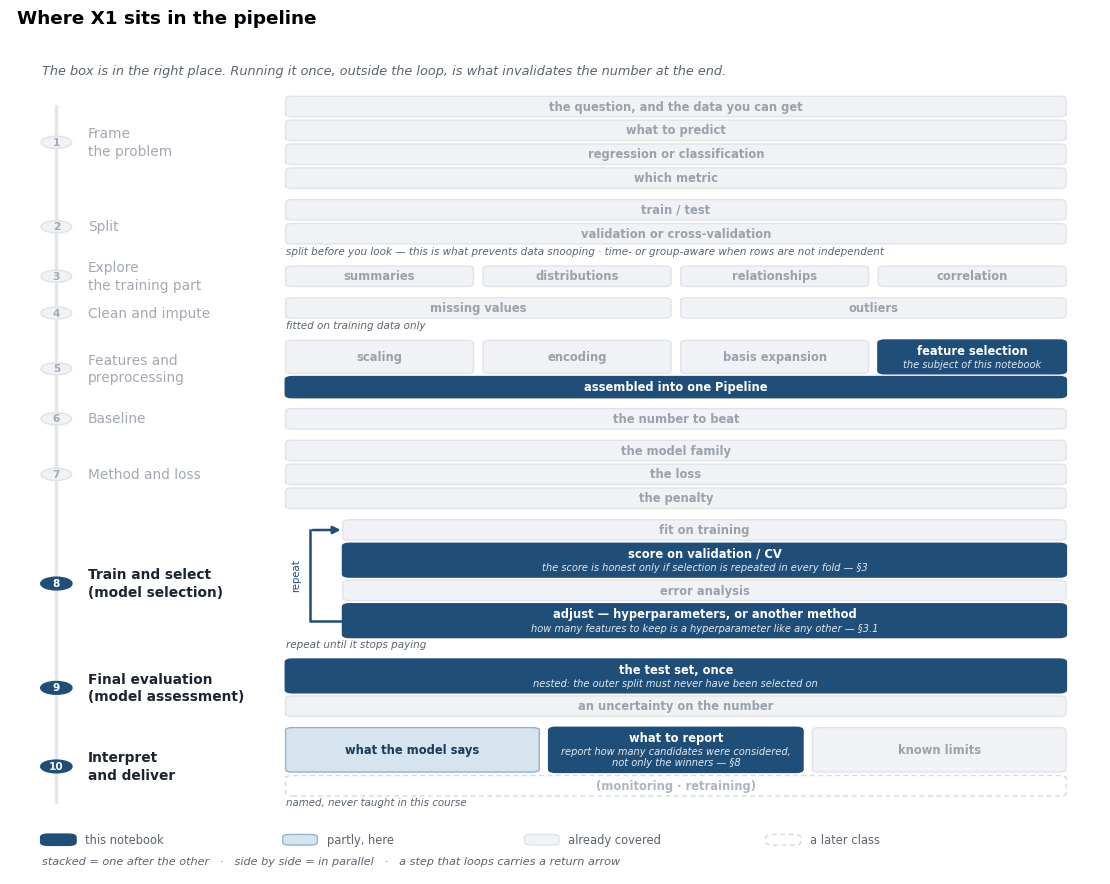

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "done", "5.4": "now",
     "5.after": "now", "6": "done", "7": "done",
     "8.1": "done", "8.2": "now", "8.3": "done", "8.4": "now",
     "9.1": "now", "9.2": "done", "10.1": "part", "10.2": "now", "10.3": "done"},
    notes={"5.4": "the subject of this notebook",
           "5.after": "the selector goes inside the Pipeline, with everything else — §4",
           "8.2": "the score is honest only if selection is repeated in every fold — §4",
           "8.4": "how many features to keep is a hyperparameter like any other — §4.1",
           "9.1": "nested: the outer split must never have been selected on",
           "10.2": "report how many candidates were considered, not only the winners — §9"},
    title="Where X1 sits in the pipeline",
    lead="The box is in the right place. Running it once, outside the loop, is what invalidates the number at the end.")
plt.show()

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)

# 1. A table where the truth is known

Real data will not tell you which of its columns matter, so every claim below is made on **simulated
data where the answer is known**: $n$ samples, $p$ features drawn independently from a standard
normal, and a target built from the first $k$ of them plus noise. Everything else is a decoy.

$$
y_i \;=\; \beta \sum_{j=1}^{k} x_{ij} \;+\; \varepsilon_i ,
\qquad \varepsilon_i \sim \mathcal{N}(0, 1)
$$

The default below is 250 samples, 500 features, 5 of which are real: wider than it is long, which is
the regime this notebook is about. A financial cross-section, a gene-expression study and a sensor
log all have that shape.

**One property of this table is deliberately unrealistic**: its columns are drawn independently of
each other. Real features arrive correlated, in groups, and that changes what every method below
does — which is why section 7 puts the correlation back and shows what breaks.

In [ ]:
def make_table(n=250, p=500, k=5, beta=0.5, seed=1):
    """A table with k informative features among p, and the truth alongside it."""
    draw = np.random.default_rng(seed)
    X = draw.normal(size=(n, p))
    y = X[:, :k] @ np.full(k, beta) + draw.normal(0, 1.0, n)
    return X, y, np.arange(k)          # the informative columns are the first k, by construction


X, y, informative = make_table()
print(f"{X.shape[0]} samples, {X.shape[1]} features, {len(informative)} of them informative")
print(f"share of the variance of y explained by the five real features: "
      f"{1 - 1.0 / np.var(y):.2f}")

250 samples, 500 features, 5 of them informative
share of the variance of y explained by the five real features: 0.61


# 2. The three families of method

`03C` §4 gave the standard taxonomy, and it is the one the field uses (Guyon & Elisseeff, *JMLR* 3,
2003). Methods differ in **what they consult** to judge a feature: the feature alone, a fitted
model's performance, or the fit itself. Everything later in this notebook is one of the three, and
section 5 measures them against each other on data whose truth is known.

- **Filter** — score each feature against the target on its own and keep the best. `SelectKBest`
  with an F-test is the usual form. Fast, blind to interactions, and it cannot notice that two
  features carry the same information.
- **Wrapper** — search over *subsets*, scoring each by fitting a model. Recursive feature
  elimination fits, drops the weakest features, and repeats. With a linear SVM this is **SVM-RFE**
  (Guyon, Weston, Barnhill & Vapnik, *Machine Learning* 46, 2002), for years the standard method in
  gene selection — and the one place where a support vector machine does select features.
- **Embedded** — the fit does the selecting. Lasso sets coefficients to exactly zero (`03C` §4); a
  tree ensemble ranks features by how much they were used (`04B` §7).

The rest of this section fills in each family. What none of them escapes is section 4: whichever you
use, it is part of the model.

## 2.1 Filters, in more than one flavour

The usual filter scores each feature by an F-test, which sees only a linear relationship with the
target. Three standard alternatives:

- **Mutual information** (`mutual_info_regression`) measures any dependence, not only a monotone
  one, at the cost of an estimate that needs more samples.
- **mRMR** — minimum redundancy, maximum relevance (Peng, Long & Ding, *IEEE PAMI* 27, 2005) —
  penalises a candidate for resembling the features already chosen, which is a filter's answer to
  section 7's correlated groups.
- **Relief and ReliefF** (Kira & Rendell, 1992; Robnik-Šikonja & Kononenko, *Machine Learning* 53,
  2003) score a feature by how well it separates each sample from its nearest neighbour of the other
  class — `05A`'s distance, used for selection.

And a filter is a multiple-testing problem, so the number kept can be set by controlling the false
discovery rate (Benjamini–Hochberg, 1995; `SelectFdr`) rather than by choosing $k$.

## 2.2 The wrapper family

Every member scores a **subset** by fitting a model to it, so every member inherits that model's
notion of what is useful — and every member pays in fits.

- **Forward selection.** Start from nothing. Add the feature that most improves the
  cross-validated score, and repeat. `SequentialFeatureSelector(direction="forward")`.
- **Backward elimination.** Start from everything and drop the least useful, one at a time. It
  cannot start at all unless the model can be fitted to all $p$ features, which rules it out when
  $p > n$ for anything without a penalty. `02A` §12's stepwise selection is these two combined.
- **Recursive feature elimination.** Backward elimination made affordable: instead of trying each
  removal, trust the model's own coefficients or importances to say who is weakest, and drop a whole
  group at a time. This is the `RFE` used above.
- **Floating search** (Pudil, Novovičová & Kittler, 1994). Forward selection with a backward step
  after each addition, so an early choice can be undone when it stops earning its place.
- **Best subset.** Try every subset. Exact, and $2^p$ — a thousand features would be more subsets
  than atoms in the observable universe. Branch-and-bound prunes the search and makes it feasible
  up to a few tens of features — but only for least-squares linear regression, which makes it the
  one entry in this list that does not carry over to an arbitrary model (*ISLR* ch. 6.1).
- **Stochastic search**: genetic algorithms, simulated annealing. Used when the space is large and
  the objective is expensive, and they make the counting problem of section 3 much worse, because
  they compare a great many subsets.

## 2.3 Embedded methods

The fit does the selecting, so there is no separate search to pay for: the lasso sets coefficients
to exactly zero (`03C` §4), and a tree ensemble reports how much each feature was used (`04B` §7).
This is the family the course already teaches, and the one Kuhn and Johnson advise starting with
(section 8).

## 2.4 Three words for "relevant", and two distinctions

The word *relevant* does more work than it can bear, and the standard repair is Kohavi and John's
three-way split (*Artificial Intelligence* 97, 1997), stated in terms of what an optimal predictor
would lose:

- **Strongly relevant** — removing it makes the best possible prediction worse. Nothing else in the
  table carries what it carries.
- **Weakly relevant** — it improves some subsets but not all: there is another feature, or a group
  of them, holding the same information. A near-copy of a strongly relevant feature is the simplest
  case. It *is* correlated with the target; it simply adds nothing once its twin is present.
- **Irrelevant** — neither of the above. It would never help any subset.

This is the vocabulary the rest of the notebook needs. When a theorem about the lasso says the
"irrelevant" features must not correlate too much with the relevant ones (section 5), it means the
features whose coefficient in the true model is **zero** — which includes every weakly relevant
near-copy, precisely the ones that are correlated with the target. The confusion is worth avoiding,
because those features are not rare: they are what section 7 is about.

- **Minimal-optimal versus all-relevant** (Nilsson et al., *JMLR* 8, 2007). Do you want the smallest
  set that predicts as well as possible, or every feature that carries information about the target?
  Lasso and RFE answer the first; methods such as **Boruta** (Kursa & Rudnicki, 2010) answer the
  second. They give different answers when features are correlated, and asking for one while
  measuring the other is a common confusion.
- **False discovery rate.** A filter is a multiple-testing problem, and the standard control is
  Benjamini–Hochberg (1995); `scikit-learn` offers it as `SelectFdr`. "Keep the top 20" controls
  nothing at all.

# 3. The winner's curse

Before selecting anything, it is worth seeing what a table of **pure noise** offers. The cell below
takes 250 samples and 500 features, none of which has any relationship with the target, and asks the
question every screening procedure asks: which feature correlates best?

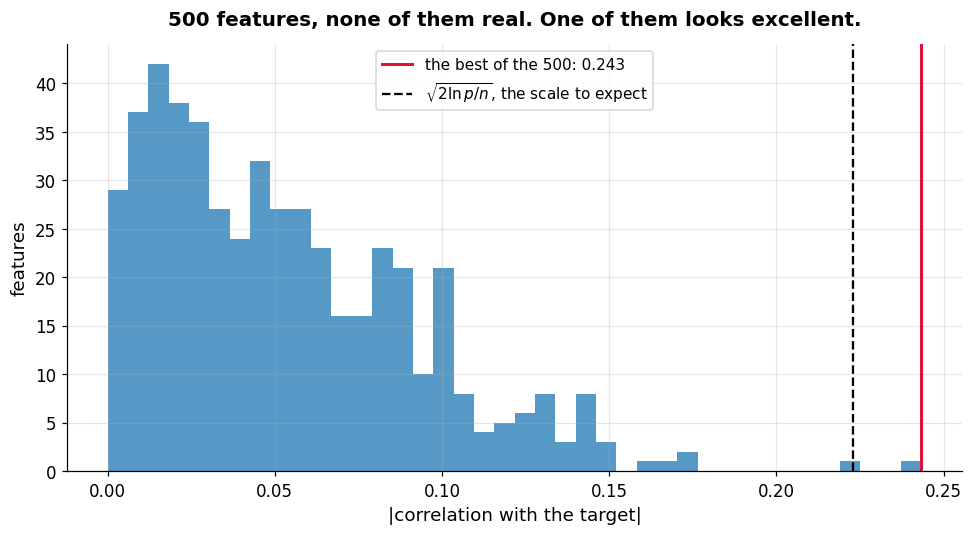

median |correlation| over the 500 features: 0.045
best |correlation|:                         0.243

R2 of the winning feature, on the data that chose it: +0.059
R2 of the same feature, on fresh data:                -0.066


In [ ]:
noise_X = rng.normal(size=(250, 500))
noise_y = rng.normal(size=250)
correlations = np.array([abs(np.corrcoef(noise_X[:, j], noise_y)[0, 1]) for j in range(500)])
winner = correlations.argmax()

fig, axis = plt.subplots(figsize=(9, 5))
axis.hist(correlations, bins=40, color="tab:blue", alpha=0.75)
axis.axvline(correlations[winner], color="crimson", linewidth=2,
             label=f"the best of the 500: {correlations[winner]:.3f}")
axis.axvline(np.sqrt(2 * np.log(500) / 250), color="black", linestyle="--", linewidth=1.5,
             label=r"$\sqrt{2\ln p / n}$, the scale to expect")
axis.set_xlabel("|correlation with the target|")
axis.set_ylabel("features")
axis.set_title("500 features, none of them real. One of them looks excellent.")
axis.legend()
plt.show()

fresh_X = rng.normal(size=(5000, 500))
fresh_y = rng.normal(size=5000)
champion = LinearRegression().fit(noise_X[:, [winner]], noise_y)
print(f"median |correlation| over the 500 features: {np.median(correlations):.3f}")
print(f"best |correlation|:                         {correlations[winner]:.3f}")
print(f"\nR2 of the winning feature, on the data that chose it: {champion.score(noise_X[:, [winner]], noise_y):+.3f}")
print(f"R2 of the same feature, on fresh data:                {champion.score(fresh_X[:, [winner]], fresh_y):+.3f}")

There is no signal in that table at all, and still one feature correlates with the target at 0.243
— five times the median. Fitted on the data that chose it, it explains 5.9% of the variance. On
fresh data it explains nothing: its $R^2$ is **negative**, meaning it is worse than predicting the
mean.

The dashed line is the scale to expect. For $p$ **independent** noise features and $n$ samples the
largest correlation grows like $\sqrt{2 \ln p / n}$, which is 0.223 here — so the observed 0.243 is
not bad luck, it is the typical outcome. Independence is the condition and it matters: correlated
candidates do not each provide a fresh chance to get lucky, so the effective number of comparisons
is smaller than $p$ and the curse is milder than this formula suggests. Milder, not absent. Note what it depends on: the number of features you
**looked at**, not the number you kept. Searching a thousand candidates and reporting the best is a
different experiment from testing one candidate, and only the second is what a p-value or an $R^2$
describes.

> **The winner's curse.** The best of many noisy estimates is biased upwards, and the more
> candidates you screen, the larger the bias. The selection step itself is what does the damage,
> whether or not the features are real.

This is the same effect as `02C` §6.1's leak, but it arrives from the other direction: there the
correlations were computed on data that included the test rows; here every correlation is honest,
and the *choice* is what misleads.

# 4. Selection is part of the model

The consequence is the single most important rule in this notebook. **A selector that looks at the
target is a fitted object, exactly like a coefficient.** Fit it on all the data and then
cross-validate what follows, and the folds have already seen, through the selection, the very rows
they are supposed to score.

The cell below runs both versions on the table of section 1 — the honest one puts `SelectKBest`
inside a `Pipeline`, so `cross_val_score` refits it in every fold, which is `02C` §6.3's remedy — and
does it at three strengths of signal.

In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=0)
print(f"{'signal beta':>12}{'selected first, then scored':>30}{'selection inside the folds':>30}")
for beta in [0.25, 0.5, 1.0]:
    X_b, y_b, truth = make_table(beta=beta)

    # WRONG: the 20 best features are chosen using every row, and only then cross-validated
    chosen = SelectKBest(f_regression, k=20).fit(X_b, y_b).get_support(indices=True)
    optimistic = cross_val_score(LinearRegression(), X_b[:, chosen], y_b, cv=folds, scoring="r2")

    # RIGHT: the selection is a step of the pipeline, refitted inside every fold
    honest = cross_val_score(make_pipeline(SelectKBest(f_regression, k=20), LinearRegression()),
                             X_b, y_b, cv=folds, scoring="r2")

    print(f"{beta:>12}{optimistic.mean():>30.3f}{honest.mean():>30.3f}")

 signal beta   selected first, then scored    selection inside the folds
        0.25                         0.322                        -0.037


         0.5                         0.597                         0.411
         1.0                         0.812                         0.799


At the weakest signal the difference decides whether the model is worth anything: **+0.322 selected
first, −0.037 done properly.** The first number would go into a report as "the model explains about
a third of the variance"; the truth is that it explains none of it. At the strongest signal the two
nearly agree, because the five real features dominate the selection whatever rows it sees. You
cannot tell in advance which regime you are in, which is the argument for always doing it the second
way.

This is one of the oldest known traps in applied machine learning, and it has a canonical treatment:
*The Elements of Statistical Learning*, ch. 7.10.2, "The wrong and right way to do cross-validation".
Ambroise and McLachlan (*PNAS* 99, 2002) found it in published cancer-classification papers, where
selecting genes before cross-validating produced near-perfect accuracies on data with no signal.

## 4.1 When there is a search as well: nested cross-validation

Selecting **how many** features to keep is itself a hyperparameter, so it must be chosen the way
`02C` §4 chooses any hyperparameter — on validation data — and the score that is finally reported
must come from data that neither the selection nor the search has seen. That is **nested**
cross-validation: an inner loop that chooses, an outer loop that scores.

In [ ]:
searched = GridSearchCV(make_pipeline(SelectKBest(f_regression), LinearRegression()),
                        {"selectkbest__k": [2, 5, 10, 20, 50, 100]},
                        cv=5, scoring="r2")

# The inner loop chooses k.  Its own best score is not an estimate of anything: it is the best of
# six, on the folds that chose it — the winner's curse again, at the level of hyperparameters.
searched.fit(X, y)
print(f"best k, chosen by the inner search: {searched.best_params_['selectkbest__k']}")
print(f"the inner search's own best score : {searched.best_score_:+.3f}   (optimistic)")

# The outer loop refits the whole search inside each of its folds, and scores on rows that the
# search never touched.
nested = cross_val_score(searched, X, y, cv=folds, scoring="r2")
print(f"nested cross-validated score      : {nested.mean():+.3f} +/- {nested.std():.3f}")

best k, chosen by the inner search: 5
the inner search's own best score : +0.566   (optimistic)


nested cross-validated score      : +0.543 +/- 0.131


The inner search reports the best of six settings on the folds that chose it; the nested score is
what the procedure is worth on data it has not seen. The gap is small here and large when the search
is large — Cawley and Talbot (*JMLR* 11, 2010) collected published results whose entire claimed
improvement was this gap. Varma and Simon (*BMC Bioinformatics* 7, 2006) measured it for feature
selection specifically.

The cost is a factor of the number of outer folds: five outer folds mean the search runs five times.
That is the price of a number you can defend.

**What that number is, precisely**, is worth stating because it is routinely over-read. A
cross-validated score estimates the average error of *the procedure* — of models fitted to other
samples of this size drawn from the same population — and not the error of the particular model you
end up shipping (Bates, Hastie & Tibshirani, 2021, who also show the usual confidence intervals for
it are too narrow). With a selection step inside, the procedure is "select, then fit", and each fold
selects a different set. The score describes that whole recipe; it says nothing about the stability
of the set, which is section 6's question.

> **Anything fitted to the target goes inside the loop.** Selection, imputation, scaling, the choice
> of $k$, the choice of model. If it looked at $y$, it is part of the model.

The rule names its own exception, and it is worth knowing because it is the one respectable way to
screen thousands of features cheaply. A filter that **never looks at the target** — dropping features
with almost no variance, say — cannot leak information about $y$, and in genomics such *independent*
filtering is used deliberately before the analysis proper (section 5.3). Scaling and imputation are
in the list above not because they see the target but because they see the *test rows*, which is
`02C` §6.3's separate reason for putting them in the pipeline.

# 5. The three families, measured

All three now run on the same table, where the truth is known. The question is not which is best in
general — section 5.3 reports what the benchmarks say about that — but what each one costs and what
each one brings back.

In [ ]:
def score_selection(name, picked, seconds):
    """How many of the five real features were found, and how much else came with them."""
    found = len(set(picked) & set(informative))
    print(f"{name:34}{len(picked):>8}{found:>7}/5{len(picked) - found:>10}{seconds:>9.1f}")


print(f"{'':34}{'kept':>8}{'real':>9}{'spurious':>10}{'seconds':>9}")

start = time.time()
by_filter = SelectKBest(f_regression, k=20).fit(X, y).get_support(indices=True)
score_selection("filter: F-test, keep 20", by_filter, time.time() - start)

start = time.time()
alpha = LassoCV(cv=5, random_state=0).fit(X, y).alpha_
by_lasso = np.flatnonzero(Lasso(alpha=alpha).fit(X, y).coef_)
score_selection("embedded: lasso, alpha by CV", by_lasso, time.time() - start)

start = time.time()
by_forest = np.argsort(RandomForestRegressor(300, n_jobs=-1, random_state=0)
                       .fit(X, y).feature_importances_)[::-1][:20]
score_selection("embedded: forest, top 20", by_forest, time.time() - start)

start = time.time()
by_wrapper = np.flatnonzero(RFE(SVR(kernel="linear"), n_features_to_select=20, step=0.2)
                            .fit(X, y).support_)
score_selection("wrapper: SVM-RFE, keep 20", by_wrapper, time.time() - start)

                                      kept     real  spurious  seconds
filter: F-test, keep 20                 20      5/5        15      0.0


embedded: lasso, alpha by CV            57      5/5        52      0.6


embedded: forest, top 20                20      5/5        15      3.0


wrapper: SVM-RFE, keep 20               20      5/5        15      1.2


All four find all five real features, and all four bring a crowd of spurious ones with them: fifteen
each for the methods that were told to keep twenty, and **fifty-two** for the lasso, whose
cross-validated $\alpha$ is tuned for prediction rather than for sparsity. That last point is not an
accident of this run but a known result: the penalty that minimises prediction error is not the one
that recovers the support, and the cross-validated choice over-selects. Two conditions are attached
to lasso selection generally, and both are routinely unmet in practice:

- the **irrepresentable** (or neighbourhood-stability) condition — the features *outside* the true
  model must not be too correlated with the ones inside it — which is essentially necessary for the
  lasso to recover the right set at all (Zhao & Yu, *JMLR* 7, 2006; Meinshausen & Bühlmann,
  *Annals of Statistics* 34, 2006). Note what "outside the model" means here: a **zero coefficient**,
  not "unrelated to the target". A near-copy of a real feature is correlated with the target — it
  inherits that correlation — and still has a coefficient of zero, because it adds nothing once the
  real one is in. Those are exactly the features the condition is about, and section 2.4 gives them
  their proper name;
- a **beta-min** condition — the real coefficients must be bounded away from zero — since a
  coefficient smaller than the noise cannot be found by any method.

So "lasso selects features" is a statement with fine print, and section 7's correlated copies are
the fine print being violated in front of you.

## 5.1 What a wrapper costs

The members of the family differ in how they search, not in what they optimise, and the cost
is what separates them in practice. The cell compares a filter, an RFE and a forward search asked for
the same thing.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SequentialFeatureSelector


def score_with_cost(name, picked, seconds, fits):
    found = len(set(picked) & set(informative))
    cost = f"{fits:,}" if fits else "none"
    print(f"{name:38}{len(picked):>6}{found:>6}/5{len(picked) - found:>10}{cost:>12}{seconds:>9.1f}")


print(f"{'':38}{'kept':>6}{'real':>8}{'spurious':>10}{'model fits':>12}{'seconds':>9}")

start = time.time()
by_filter = SelectKBest(f_regression, k=10).fit(X, y).get_support(indices=True)
score_with_cost("filter: F-test, keep 10", by_filter, time.time() - start, 0)

start = time.time()
eliminated = RFE(Ridge(), n_features_to_select=10, step=0.2).fit(X, y)
score_with_cost("wrapper: RFE with ridge", np.flatnonzero(eliminated.support_),
                time.time() - start, 18)

start = time.time()
forward = SequentialFeatureSelector(Ridge(), n_features_to_select=10, direction="forward",
                                    cv=3, n_jobs=-1).fit(X, y)
# every candidate is scored by 3-fold cross-validation, at every one of the ten steps
planned = 3 * sum(X.shape[1] - step for step in range(10))
score_with_cost("wrapper: forward selection", np.flatnonzero(forward.get_support()),
                time.time() - start, planned)

                                        kept    real  spurious  model fits  seconds
filter: F-test, keep 10                   10     5/5         5        none      0.0
wrapper: RFE with ridge                   10     5/5         5          18      0.0


wrapper: forward selection                10     5/5         5      14,865     69.8


**All three return the same five real features and five spurious ones, and they differ by four
orders of magnitude in cost.** The filter scores each feature once. RFE refits about eighteen times.
Forward selection fits **14,865** models: at each of ten steps it cross-validates every remaining
candidate.

That is the honest summary of wrappers on a wide table. They are worth their cost when the model is
cheap, the features few, and interactions matter — a feature that is useless alone but valuable
beside another is invisible to a filter and can be found by a forward search. They are a poor bargain
when $p$ is in the hundreds, and two warnings apply beyond the arithmetic:

- **Every subset compared is a trial.** Section 3's winner's curse applies to subsets exactly as it
  applies to features, and a wrapper compares thousands. `X2` §5 is the same problem in its
  sharpest form.
- **The whole search is part of the model.** A wrapper run once on all the data, then
  cross-validated, is section 4's error with more steps in it. Inside a `Pipeline` and inside the
  outer folds is the only honest arrangement — and the cost above is then multiplied by the number
  of outer folds.

## 5.2 Letting the data set the threshold: probe features

"Keep the top 20" answers a question nobody asked. The number of real features is not known, and
every method above needs it supplied. There is a trick that lets the data answer instead, and it is
the idea behind **Boruta** (Kursa & Rudnicki, *Journal of Statistical Software* 36, 2010).

Make a **shadow** copy of every feature by shuffling its values, which destroys any relationship
with the target while preserving the feature's distribution exactly. Fit the model on the real and
shadow features together. Any real feature that scores below the best shadow has not shown that it
does anything a decoy could not do by luck. Repeat, because "the best shadow" is itself a random
quantity, and keep the features that win often.

In [ ]:
probe_rng = np.random.default_rng(0)
rounds = 20
wins = np.zeros(X.shape[1])

start = time.time()
for _ in range(rounds):
    # the same columns, with their rows shuffled: same distribution, no relationship with y
    shadows = np.column_stack([probe_rng.permutation(X[:, j]) for j in range(X.shape[1])])
    importance = RandomForestRegressor(200, n_jobs=-1, random_state=0).fit(
        np.column_stack([X, shadows]), y).feature_importances_
    wins += importance[:X.shape[1]] > importance[X.shape[1]:].max()

print(f"{rounds} rounds, {time.time() - start:.0f} s\n")
print(f"the five real features beat every shadow in {wins[:5].astype(int)} rounds of {rounds}")
print(f"the luckiest noise feature managed {int(wins[5:].max())}")
kept = np.flatnonzero(wins >= rounds / 2)
print(f"\nkeeping what wins at least half the time: {len(kept)} features, "
      f"{len(set(kept) & set(informative))} of them real, {len(kept) - len(set(kept) & set(informative))} spurious")

20 rounds, 74 s

the five real features beat every shadow in [20 20 16 20 20] rounds of 20
the luckiest noise feature managed 2

keeping what wins at least half the time: 5 features, 5 of them real, 0 spurious


The five real features beat every decoy in 16 to 20 rounds out of 20; the luckiest noise feature
managed 2. Keeping whatever wins at least half the time returns **exactly the five**, with nothing
supplied by hand — no $k$, no threshold on an importance score, no $\alpha$.

Four things to know before using it.

- It answers the **all-relevant** question of section 2.4, not the minimal-optimal one: it keeps every
  feature carrying information, including near-copies of one another (section 7).
- **It inherits whatever biases the importance measure has.** With a tree ensemble's impurity
  importance that means the bias `04B` §7.1 demonstrated, towards features offering many split
  points. A decoy built by shuffling a feature has the *same* number of split points as the
  original, which cancels much of that bias — but not the part that comes from correlations between
  real features.
- **Shuffling breaks a feature's relationship with everything, not only with the target.** The
  question it answers is therefore "is this feature better than an unrelated column?", which is not
  the same as "does it add anything given the others".
- The threshold used here is a rule of thumb. Boruta proper compares each feature's wins against a
  binomial null over rounds and corrects for multiple testing, which is the same idea with the
  arithmetic done properly.

It costs a model fit per round on twice as many columns, so it is a method for tables of hundreds of
features, not hundreds of thousands.

## 5.3 Which of them actually works best?

The taxonomy suggests a hierarchy — filters are crude, wrappers are thorough, embedded methods are
elegant — and the comparative literature does not support it. Three studies are worth knowing.

**Simple filters do better than they have any right to.** Haury, Gestraud and Vert (*PLoS ONE* 6,
2011) compared **32 selection methods** on four breast-cancer gene-expression datasets, scoring
accuracy, stability and interpretability. Their conclusion: *simple filter methods generally
outperform more complex embedded or wrapper methods, ensemble feature selection has generally no
positive effect, and overall a plain Student's t-test gives the best results.*

**The best filter may not look at the target at all — under a condition worth stating.** Bommert and
colleagues (*Briefings in Bioinformatics* 23, 2022) benchmarked 14 filters on 11 high-dimensional
gene-expression survival datasets and recommend the **variance filter** — rank each feature by its
variance, keep the most variable — for accuracy and because it gives by far the most *stable* sets.
They also report that every filter producing accurate models kept only a few features.

**Variance is not the point; it is a stand-in for something else.** What a measured feature varies
by is signal plus measurement noise, so ranking on total variance ranks on signal **only if the
noise is about the same for every feature** — which is a reasonable thing to assume for thousands of
readings from one instrument, and is why the filter earns its place on a single expression platform.
Read that way, the variance filter is an estimate of each feature's **signal-to-noise ratio**, and
the ranking is incidental to it.

The genomics literature acts on exactly that reading, and most of its machinery exists because the
assumption usually fails.

- **When the noise floor is not flat, it is made flat.** In microarray and RNA-seq data the noise
  grows with the intensity, so a **variance-stabilising transformation** is applied first, chosen so
  that the variance is approximately constant across the whole intensity range (Huber et al., 2002;
  the `DESeq2` and `sctransform` transformations are the modern descendants). Only afterwards does a
  variance ranking mean what it appears to mean.
- **Or the noise is estimated and subtracted.** Single-cell analysis fits the *technical* variance
  as a function of a gene's mean and keeps the genes whose variability exceeds that trend
  (Brennecke et al., *Nature Methods* 10, 2013). `scran`'s `modelGeneVar` splits each gene's total
  variance into a technical and a **biological** component and ranks on the second, precisely
  because the log transform is not a variance-stabilising one and total variance otherwise tracks
  abundance rather than biology.
- **Where the relationship is structural, so is the bias.** DNA methylation values are bounded in
  $[0, 1]$, so their variance is largest near 0.5 and filtering on standard deviation selects probes
  with middling means rather than informative ones.

**Which is why it does not transfer to a table of mixed units.** Millimetres, degrees and ratios as
in `05A` have no common noise floor — the ranking would be a ranking of units — and Guyon and
Elisseeff's second checklist question, *are your features commensurate?*, is this question asked
before the fact.

> **And note the tension with `05A` §1**, which is real rather than apparent. Standardising every
> feature to variance 1 is required before measuring distances, and it destroys exactly the
> information this filter uses: after scaling, every variance is 1 and the filter has nothing left
> to rank. The two procedures answer different questions — *which features carry signal* against
> *how far apart are two samples* — and a pipeline that needs both does the filtering first.

What makes the idea respectable in its own setting is that it **never looks at the target**, so it
cannot leak in the sense of section 4. That is *non-specific* or **independent filtering**, and the
argument for it is that a filter statistic independent of the test statistic under the null can
discard features without invalidating what follows — in the original microarray application,
filtering by overall variance before a t-test raised the number of discoveries by about 50%
(Bourgon, Gentleman & Huber, *PNAS* 107, 2010).

**And no filter is best everywhere; the choice interacts with the model that follows.** Bommert et
al. (*Computational Statistics & Data Analysis* 143, 2020) ran 22 filters against 16
high-dimensional datasets, scoring each **filter–classifier pair** for accuracy and run time. One
finding worth carrying into `04B` §7: a random forest's impurity and permutation importances,
computed from the same forest, rank features so differently that their mean rank correlation is
0.46. "Tree importance" is not one method.

**Why the simple methods win is section 3 again.** Every comparison a selector makes is an
opportunity to fit noise, and the elaborate methods make vastly more comparisons: a forward search
over 500 features compares thousands of subsets, a t-test compares nothing. When $p \gg n$, that
cost is usually larger than whatever the search gains.

### What the same literature says to combine

- **Screen with a cheap filter, then search with something that knows the model.** This is Guyon and
  Elisseeff's own advice (*JMLR* 3, 2003) and the standard shape of a genomics pipeline: a univariate
  filter cuts thousands of features to hundreds, and a lasso or an RFE works on what survives. The
  screen is part of the model and goes inside the folds (section 4).
- **For stability rather than accuracy, wrap an embedded method in resampling.** Stability selection
  (section 6) does not promise a better score; it promises a set that does not change when the
  sample does, which is what a published signature needs. Note the tension with Haury et al., who
  found no *accuracy* benefit from ensembling — the two claims are about different things, and
  saying which one you are buying is part of reporting it.
- **For the all-relevant question, probe features on top of a tree ensemble** (section 5.2).
- **For correlated groups, use a method that knows about them**: mRMR among filters, elastic net
  among embedded methods, or cluster-then-represent (`04B` §7.2). Section 7 shows what happens
  otherwise.
- **Whatever the combination, nested cross-validation around it** (section 4.1). The combination is
  the model.

> **Two cautions about this evidence.** It comes overwhelmingly from bioinformatics, where
> $p \gg n$, features are correlated in blocks, and the data are a fixed cross-section. A table of
> thirty engineered features with 100,000 rows is a different regime, and there an embedded method
> inside a boosted model is the usual default. And none of these benchmarks studies data that drift
> in time, which is `X2`'s subject and where the ranking of methods is least settled.

# 6. Ask how often, not which

A single run gives a single set. Run it again on a slightly different sample and the set changes —
and there is no way to tell, from one run, which members were chosen for a reason.

**Stability selection** (Meinshausen & Bühlmann, *JRSS-B* 72, 2010) answers the better question. Fit
the selector many times on random halves of the data, count how often each feature is kept, and keep
those whose frequency passes a threshold. The count is the output; the individual runs are not.

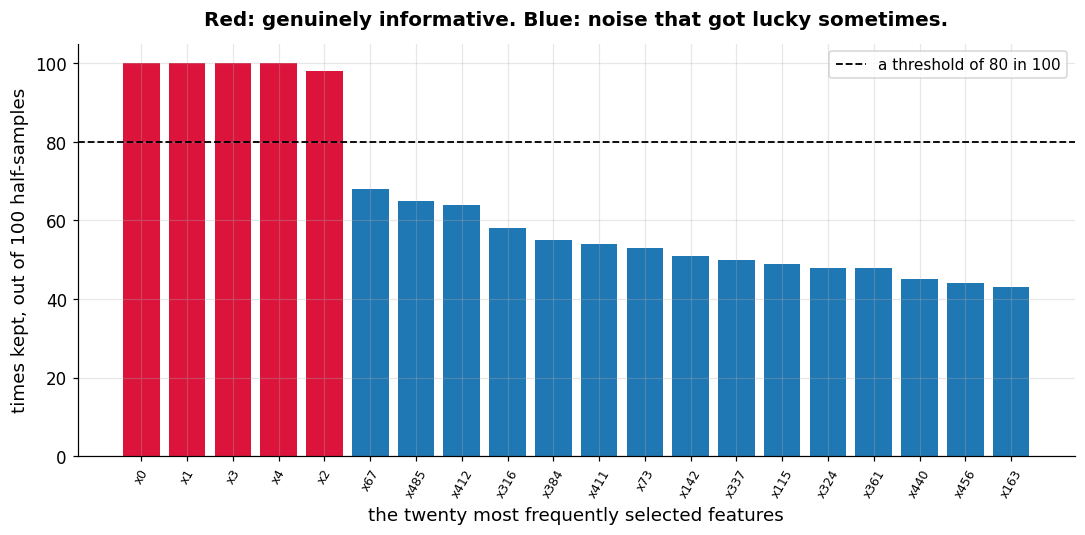

the five real features were kept   : [100 100  98 100 100] times out of 100
the most persistent noise feature  : 68 times
noise features above the threshold : 0

for comparison, one lasso on all the data kept 57 features, 52 of them spurious


In [ ]:
def selection_frequency(X_data, y_data, alpha, rounds=100, seed=0):
    """How often each feature survives a lasso fitted to a random half of the rows."""
    draw = np.random.default_rng(seed)
    counts = np.zeros(X_data.shape[1])
    for _ in range(rounds):
        rows = draw.choice(len(y_data), len(y_data) // 2, replace=False)
        counts[Lasso(alpha=alpha).fit(X_data[rows], y_data[rows]).coef_ != 0] += 1
    return counts


counts = selection_frequency(X, y, alpha)
order = np.argsort(counts)[::-1]

fig, axis = plt.subplots(figsize=(10, 5))
axis.bar(range(20), counts[order[:20]],
         color=["crimson" if j in informative else "tab:blue" for j in order[:20]])
axis.axhline(80, color="black", linestyle="--", linewidth=1.2, label="a threshold of 80 in 100")
axis.set_xticks(range(20), [f"x{j}" for j in order[:20]], rotation=60, fontsize=8)
axis.set_xlabel("the twenty most frequently selected features")
axis.set_ylabel("times kept, out of 100 half-samples")
axis.set_title("Red: genuinely informative. Blue: noise that got lucky sometimes.")
axis.legend()
plt.show()

print(f"the five real features were kept   : {counts[informative].astype(int)} times out of 100")
print(f"the most persistent noise feature  : {int(counts[5:].max())} times")
print(f"noise features above the threshold : {int((counts[5:] >= 80).sum())}")
print(f"\nfor comparison, one lasso on all the data kept {len(by_lasso)} features, "
      f"{len(by_lasso) - len(informative)} of them spurious")

The five real features survive 98 to 100 times out of 100. The luckiest noise feature manages 68. A
threshold at 80 therefore recovers exactly the five, where the single lasso of section 5 offered
fifty-seven features with no way of telling which were which.

That is the practical value: **a frequency is interpretable and a ranking is not.** It also costs
what it looks like it costs — a hundred fits instead of one — which is affordable for a lasso and is
not for a deep network, a limitation worth knowing before promising it.

> Stability selection has assumptions of its own, and the exchange of a threshold for an error bound
> is not free; Shah and Samworth (*JRSS-B* 75, 2013) give the version with the guarantee. Treat the
> threshold as a knob you chose, and say what you chose.

# 7. What correlated features do to all of this

`03C` §4 showed lasso choosing arbitrarily between `s1` and `s2`, two blood measurements correlated
at 0.90. The same effect breaks the method of section 6, and it is worth seeing directly.

The cell adds four near-copies of the first real feature — correlations around 0.95, as if the same
quantity had been recorded by five instruments — and repeats both the fit and the frequency count.

In [ ]:
copy_rng = np.random.default_rng(5)
copies = np.column_stack([X[:, 0] + copy_rng.normal(0, 0.33, len(y)) for _ in range(4)])
X_copies = np.column_stack([X, copies])
family = [0] + [500 + j for j in range(4)]           # the original and its four near-copies

print("correlation of each copy with the original:",
      [round(float(np.corrcoef(X_copies[:, 0], X_copies[:, 500 + j])[0, 1]), 2) for j in range(4)])

alpha_copies = LassoCV(cv=5, random_state=0).fit(X_copies, y).alpha_
coefficients = Lasso(alpha=alpha_copies).fit(X_copies, y).coef_
print(f"\nlasso coefficients on the five members of the family: {coefficients[family].round(3)}")
print(f"   kept: {int((coefficients[family] != 0).sum())} of 5")

counts_copies = selection_frequency(X_copies, y, alpha_copies)
print(f"\nhow often each member of the family survives: {counts_copies[family].astype(int)} / 100")
print(f"the other four real features, for comparison: {counts_copies[1:5].astype(int)} / 100")

correlation of each copy with the original: [0.96, 0.96, 0.95, 0.96]



lasso coefficients on the five members of the family: [0.096 0.339 0.    0.    0.   ]
   kept: 2 of 5



how often each member of the family survives: [34 91 12 27 30] / 100
the other four real features, for comparison: [100  98 100 100] / 100


The five members of the family carry the same information, and between them they hold one real
effect. Lasso keeps two of them and assigns most of the weight to a copy rather than to the
original. Worse, the frequencies collapse: the members are selected 34, 91, 12, 27 and 30 times,
while the four untouched real features stay at 98 to 100. **A threshold of 80 now discards four of
the five, and would have discarded the effect entirely if the copies had shared the votes more
evenly.**

Nothing is wrong with the data, and nothing is wrong with stability selection. The unit of analysis
is wrong. When features come in correlated groups, the group is what carries the information, and it
is what should be selected:

- **Cluster first, then treat each cluster as one feature** — `04B` §7.2's recipe: Spearman
  correlations, hierarchical clustering, one representative per cluster.
- **Group lasso** (Yuan & Lin, *JRSS-B* 68, 2006) penalises whole groups, so a group enters or
  leaves together, when the grouping is known in advance.
- **Elastic net** (`03C` §4) is the soft version: its L2 part makes correlated features enter
  together rather than one at a time.

> **Check the correlation structure before you select, not after.** Every method in section 5
> assumes the features are distinguishable. When they are not, the method will still return an
> answer, and the answer will be arbitrary.

# 8. Which method, for which problem

Nothing above chooses for you, and the choice does depend on the problem: on how many features
there are against how many samples, on how noisy the target is, on whether the features are
correlated, on what you already know, and on the model that will consume the result. This section
collects what the comparative literature actually supports. Where a row has no citation it is not a
finding but a convention, and is marked as such.

Before the table, the honest summary of all of it, from the authors of the field's standard review:
their checklist ends with the caution that it is heuristic, and that *"the only recommendation that
is almost surely valid is to try the simplest things first"* (Guyon & Elisseeff, *JMLR* 3, 2003).

| Your situation | What the evidence suggests | Where it comes from |
|---|---|---|
| **You already know which quantities matter** | Do not search. Build those features, and spend the effort on constructing better ones | Guyon & Elisseeff's checklist, step 1 |
| **Features on different scales** | Normalise before anything else; a distance or a penalty is meaningless otherwise | Guyon & Elisseeff, step 2; `05A` §1; `03C` §2 |
| **$p \gg n$** (thousands of features, tens or hundreds of samples) | A univariate filter and a strongly regularised model. Expect simple to beat elaborate: over 32 methods on gene-expression data, plain filters generally beat wrappers and embedded methods, and a t-test was best overall | Haury, Gestraud & Vert, *PLoS ONE* 6, 2011 |
| **$p \gg n$, and every feature is the same measurement with the same noise floor** (one assay, one instrument, after a variance-stabilising transformation if the noise tracks the level) | A variance filter is then a defensible screen — it estimates each feature's signal-to-noise ratio and never touches the target. On mixed units, or after standardising, it is meaningless — section 5.3 | Bommert et al., *Brief. Bioinform.* 23, 2022; Bourgon, Gentleman & Huber, *PNAS* 107, 2010; Huber et al., 2002 |
| **$p \gg n$ and the selected set will be published** | Stability selection: subsample, refit, keep what recurs. It buys reproducibility, not accuracy | Meinshausen & Bühlmann, *JRSS-B* 72, 2010; section 6 |
| **Low signal-to-noise target** (finance, and much of the social world) | Shrink rather than search: the lasso wins at low SNR, where best subset and stepwise overfit; the **relaxed lasso** was the overall winner. Established for **linear regression with a sparse truth**, which is the condition — the comparison has not been run for tree ensembles or networks | Hastie, Tibshirani & Tibshirani, *Statistical Science* 35, 2020 |
| **High signal-to-noise target** (engineered or physical features) | Best subset and forward stepwise become competitive, and the relaxed lasso matches them | the same paper, under the same conditions |
| **The model is a tree ensemble**, and $n$ is comfortable | Often select nothing: trees are resistant to irrelevant predictors, and `05A` §4.2 measured fifty noise columns costing a boosted model 0.01 of ROC AUC. Prune for cost, latency or interpretation rather than for accuracy | Kuhn & Johnson, *Feature Engineering and Selection*, ch. 10; `05A` §4.2 |
| **…but the relevant features are a small fraction of a large table** | The resistance runs out: a forest drawing $\sqrt{p}$ features at each split rarely offers a relevant one, and `04B` §4 measured that collapse. Here a screen helps the trees too | ESL ch. 15.3.4, quoted in `04B` §9.1; `04B` §4 |
| **The model uses distances or a linear boundary** (kNN, SVM, linear regression) | Selection matters here: in the same simulation, linear regression and SVMs degraded badly with noise features while the lasso was stable and kNN was poor throughout | Kuhn & Johnson, ch. 10; `05A` §4.2 measured it |
| **Features arrive in correlated groups** | A method that knows about the grouping: elastic net, group lasso, mRMR, or cluster-then-represent | Zou & Hastie, 2005; Yuan & Lin, 2006; Peng et al., 2005; `04B` §7.2; section 7 |
| **The question is "which quantities carry information"** rather than "which subset predicts best" | Probe features (section 5.2). It is the all-relevant question, and a minimal-optimal method answers a different one | Nilsson et al., *JMLR* 8, 2007; Kursa & Rudnicki, 2010 |
| **Few features (tens), a cheap model, interactions suspected** | A wrapper is affordable and can see what a filter cannot | *ISLR* ch. 6.1; Kuhn & Johnson, ch. 11 |
| **A neural network on tabular data** | Filters or embedded methods; wrappers are too expensive to run | the tabular feature-selection benchmark of NeurIPS 2023 |
| **Always, whatever you chose** | The selection goes inside the resampling loop, the reported score comes from nested cross-validation, and the number of candidates screened is part of the result | Ambroise & McLachlan, 2002; Varma & Simon, 2006; Kuhn & Johnson, ch. 10; sections 4 and 9 |

Kuhn and Johnson's own working rule is worth quoting as a starting point rather than a law: begin
with an intrinsic method — a lasso, or a tree ensemble's own importances — and see what it gives
before reaching for anything more elaborate.

**The two axes that matter most** are how wide the table is and how noisy the target is, and they
are not independent of each other. The figure below places the recommendations on those two axes.

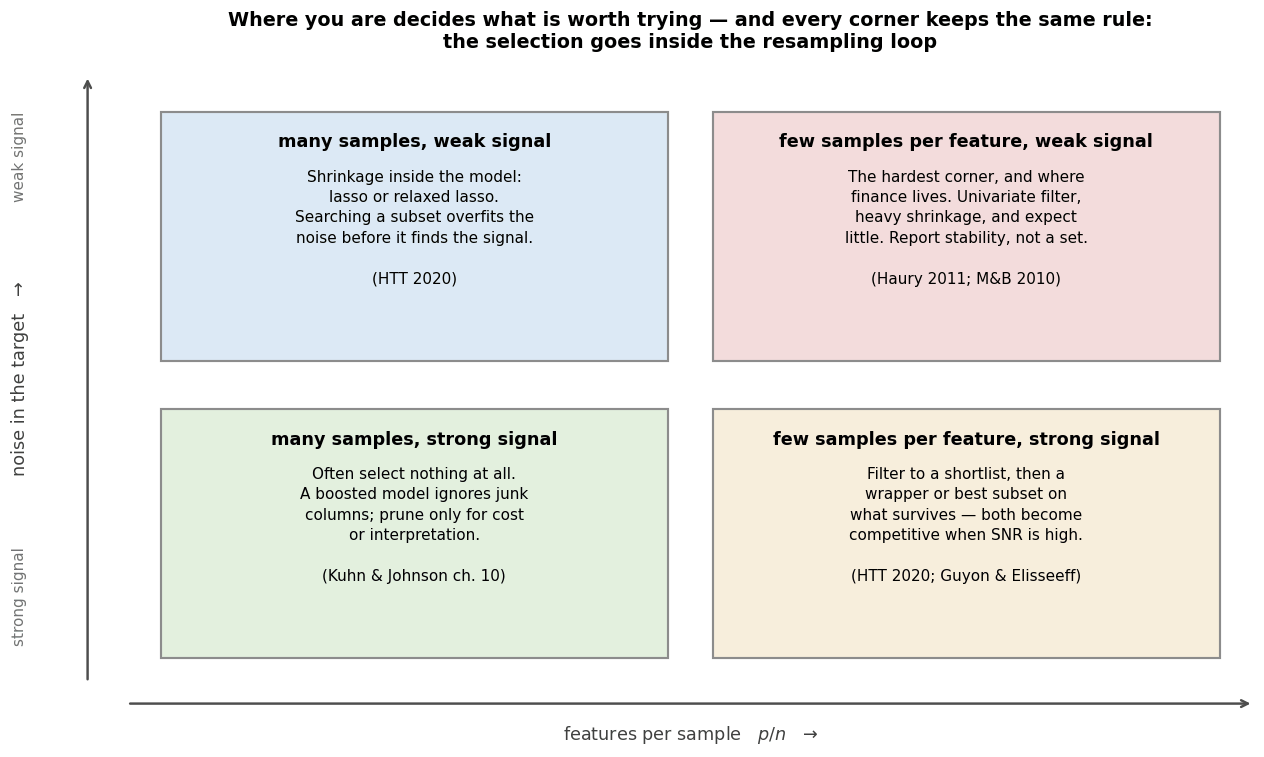

In [ ]:
fig, axis = plt.subplots(figsize=(11.5, 7))
axis.set_xlim(0, 10); axis.set_ylim(0, 10); axis.axis("off")

quadrants = [
    (0.3, 5.3, "#DCE9F5", "many samples, weak signal",
     "Shrinkage inside the model:\nlasso or relaxed lasso.\nSearching a subset overfits the\nnoise before it finds the signal.\n\n(HTT 2020)"),
    (5.2, 5.3, "#F3DCDC", "few samples per feature, weak signal",
     "The hardest corner, and where\nfinance lives. Univariate filter,\nheavy shrinkage, and expect\nlittle. Report stability, not a set.\n\n(Haury 2011; M&B 2010)"),
    (0.3, 0.4, "#E3F0DE", "many samples, strong signal",
     "Often select nothing at all.\nA boosted model ignores junk\ncolumns; prune only for cost\nor interpretation.\n\n(Kuhn & Johnson ch. 10)"),
    (5.2, 0.4, "#F7EEDC", "few samples per feature, strong signal",
     "Filter to a shortlist, then a\nwrapper or best subset on\nwhat survives — both become\ncompetitive when SNR is high.\n\n(HTT 2020; Guyon & Elisseeff)"),
]
for x, y, colour, title, body in quadrants:
    axis.add_patch(plt.Rectangle((x, y), 4.5, 4.1, facecolor=colour, edgecolor="0.55", linewidth=1.4))
    axis.text(x + 2.25, y + 3.75, title, ha="center", va="top", fontsize=11.5, fontweight="bold")
    axis.text(x + 2.25, y + 3.15, body, ha="center", va="top", fontsize=10, linespacing=1.45)

axis.annotate("", xy=(10, -0.35), xytext=(0, -0.35), annotation_clip=False,
              arrowprops={"arrowstyle": "->", "color": "0.3", "linewidth": 1.6})
axis.text(5, -0.95, "features per sample   $p/n$   →", ha="center", fontsize=11.5, color="0.25")
axis.annotate("", xy=(-0.35, 10), xytext=(-0.35, 0), annotation_clip=False,
              arrowprops={"arrowstyle": "->", "color": "0.3", "linewidth": 1.6})
axis.text(-0.95, 5, "noise in the target   →", rotation=90, va="center", ha="center",
          fontsize=11.5, color="0.25")
axis.text(-0.95, 9.4, "weak signal", rotation=90, va="top", ha="center", fontsize=10, color="0.45")
axis.text(-0.95, 0.6, "strong signal", rotation=90, va="bottom", ha="center", fontsize=10, color="0.45")
axis.set_title("Where you are decides what is worth trying — and every corner keeps the same rule:\n"
               "the selection goes inside the resampling loop", fontsize=12.5, pad=18)
plt.show()

Three things the figure cannot say, and they are the ones that decide most real cases.

**Prior knowledge beats every box.** If it is already known that three of the forty measurements
carry the physics, the table above is irrelevant: use them, and put the effort into constructing
better features from them. That is the first step of Guyon and Elisseeff's checklist and the one
they are most confident about.

**Noise in the *features* is not the same as noise in the target.** A feature measured badly is
still informative if the measurement error is small compared with its spread; what kills a selector
is a feature that is *irrelevant*, not one that is imprecise. The demonstrations in this notebook
add irrelevant columns, which is the harder case.

**The model decides how much any of this matters.** `05A` §4.2 measured it: fifty noise columns
cost a nearest-neighbour model 0.12 of ROC AUC and a boosted model 0.01. The same fifty columns
would cost a linear model or an SVM a great deal, and Kuhn and Johnson's simulation reports exactly
that ordering. **Feature selection is worth most where the model is least able to ignore a useless
column.**

## 8.1 When ten features are known and five hundred are candidates

The commonest version of "prior knowledge" is not certainty about everything. It is a table in two
blocks: a handful of features that are known to matter — measured for a reason, established in the
literature, or simply the ones the instrument was built to record — and a long tail of candidates
that might. Treating all 510 as equals throws away the only reliable information in the problem.

The medical-statistics literature has the right framing, because it is that field's standing
problem: a clinical model of known risk factors, and a few thousand candidate molecular markers.
Two named methods, both from the same group:

- **IPF-LASSO** (Boulesteix et al., 2017) gives each **block** of features its own penalty factor,
  so the trusted block is shrunk less than the speculative one, and the factors are estimated from
  the data.
- **Priority-Lasso** (Klau, Jurinovic, Hornung, Herold & Boulesteix, *BMC Bioinformatics* 19, 2018)
  puts the blocks in a **priority order**: fit the first block, then fit the next block to what the
  first left unexplained, by carrying the first block's fitted values as an **offset**. Used with
  clinical variables first, the known block is left **unpenalised** and the candidates must earn
  their place against it.

Both encode the same idea, and it is the one to take away: **penalise what you are unsure of, not
what you know.** In `scikit-learn` there is no per-feature penalty factor, but the priority version
needs none — fitting the known block, then selecting among the candidates on the **residual**, is
exactly the offset step. That equivalence is for squared-error regression; in a logistic or survival
model the known block enters the second fit as an **offset** rather than by subtraction, which is
what `glmnet` and the `prioritylasso` package provide and what the original papers use.

The cell compares that with the naive alternative of one lasso over all 510 columns. The data have
ten known features and five real candidates hidden among five hundred, all with the same
coefficient, so the candidates genuinely carry a third of the signal.

In [ ]:
known_count, candidate_count, real_candidates = 10, 500, 5


def two_block_table(n, seed=3):
    """Ten features known to matter, five hundred candidates of which five are real."""
    draw = np.random.default_rng(seed)
    columns = draw.normal(size=(n, known_count + candidate_count))
    coefficients = np.zeros(known_count + candidate_count)
    coefficients[:known_count] = 0.4                                   # the known block
    coefficients[known_count:known_count + real_candidates] = 0.4      # the real candidates
    return columns, columns @ coefficients + draw.normal(0, 1, n)


X_blocks, y_blocks = two_block_table(250)
known_cols = np.arange(known_count)
real_cols = np.arange(known_count, known_count + real_candidates)
noise_cols = np.arange(known_count + real_candidates, known_count + candidate_count)

# (a) everything on an equal footing
alpha_all = LassoCV(cv=5, random_state=0).fit(X_blocks, y_blocks).alpha_
flat = Lasso(alpha=alpha_all).fit(X_blocks, y_blocks).coef_
print(f"one lasso over all {known_count + candidate_count} columns: keeps {int((flat != 0).sum())} features"
      f"  — {int((flat[known_cols] != 0).sum())}/10 known, {int((flat[real_cols] != 0).sum())}/5 real candidates,"
      f" {int((flat[noise_cols] != 0).sum())} noise")

# (b) the known block forced in, unpenalised; the candidates selected on what it leaves behind
baseline = LinearRegression().fit(X_blocks[:, known_cols], y_blocks)
unexplained = y_blocks - baseline.predict(X_blocks[:, known_cols])
alpha_rest = LassoCV(cv=5, random_state=0).fit(X_blocks[:, known_count:], unexplained).alpha_
earned = Lasso(alpha=alpha_rest).fit(X_blocks[:, known_count:], unexplained).coef_
print(f"known block forced in, candidates on the residual: keeps {int((earned != 0).sum())} of the 500"
      f"  — {int((earned[:real_candidates] != 0).sum())}/5 real, {int((earned[real_candidates:] != 0).sum())} noise")

one lasso over all 510 columns: keeps 58 features  — 10/10 known, 5/5 real candidates, 43 noise


known block forced in, candidates on the residual: keeps 15 of the 500  — 5/5 real, 10 noise


Both find all five real candidates. The difference is what else comes with them: the flat lasso
keeps **43 noise columns**, the prioritised version **10**. The known block is what made the
difference — once its contribution is removed, a candidate has to explain something the ten do not,
and most noise columns cannot.

The next question is the one that decides whether the five hundred were worth collecting at all:
**do they add anything?** The baseline to beat is not the mean (`04A` §13's dummy) but the model
built from the ten features already known — the *incremental value* of the new block. The cell
measures it, with the selection repeated inside every fold, at four sample sizes.

In [ ]:
def incremental_value(X_data, y_data):
    """Cross-validated R2 of the known block alone, and with candidates selected inside each fold."""
    alone, extended = [], []
    for train, test in KFold(5, shuffle=True, random_state=0).split(X_data):
        block = LinearRegression().fit(X_data[train][:, known_cols], y_data[train])
        alone.append(r2(y_data[test], block.predict(X_data[test][:, known_cols])))

        left_over = y_data[train] - block.predict(X_data[train][:, known_cols])
        alpha = LassoCV(cv=5, random_state=0).fit(X_data[train][:, known_count:], left_over).alpha_
        chosen = np.flatnonzero(Lasso(alpha=alpha).fit(X_data[train][:, known_count:], left_over).coef_)
        columns = np.r_[known_cols, known_count + chosen] if len(chosen) else known_cols
        together = LinearRegression().fit(X_data[train][:, columns], y_data[train])
        extended.append(r2(y_data[test], together.predict(X_data[test][:, columns])))
    return np.mean(alone), np.mean(extended)


r2 = lambda truth, predicted: 1 - np.mean((truth - predicted) ** 2) / np.var(truth)

print(f"{'samples':>9}{'the ten alone':>16}{'ten + candidates':>19}{'gain':>9}")
for n in [250, 500, 1000, 4000]:
    X_n, y_n = two_block_table(n)
    alone, extended = incremental_value(X_n, y_n)
    print(f"{n:>9}{alone:>16.3f}{extended:>19.3f}{extended - alone:>+9.3f}")
print("\nwith these coefficients the candidates are worth about +0.24 of R2 if they could be "
      "identified perfectly")

  samples   the ten alone   ten + candidates     gain


      250           0.379              0.395   +0.017


      500           0.481              0.633   +0.153


     1000           0.470              0.630   +0.160


     4000           0.453              0.691   +0.238

with these coefficients the candidates are worth about +0.24 of R2 if they could be identified perfectly


**At 250 samples the five hundred candidates are worth +0.017**, against the +0.24 they would be
worth if somebody handed you the five real ones. Almost the entire value of the new block is eaten
by the cost of finding it: ten spurious columns enter with the five real ones, and each of them
carries an estimated coefficient that is noise. At 500 samples the gain is +0.153, and by 4,000 it
is +0.238 — essentially all of what is there.

The run illustrates two statements that come from the literature rather than from it. The first is
that a new block of features is a question of **incremental value** — what it adds over the model
already in use — so the comparison is made against that model and not against nothing (Steyerberg
et al., *European Journal of Clinical Investigation* 42, 2012, reviewing how this is done and
misdone). The second is that how much of that value can be recovered is a **sample-size** question:
the minimum sample needed to fit a prediction model without overfitting grows with the number of
*candidate* predictors, not merely with the number finally kept (Riley et al., *Statistics in
Medicine* 38, 2019). Five hundred candidates are five hundred candidates whether or not five of
them survive.

Together those say what the table shows: the incremental comparison — the ten alone against the ten
plus whatever survives — belongs in the report whenever a new block of features is proposed, and a
disappointing result is as likely to mean "not enough samples to identify them" as "nothing there".

Three practical notes.

**A candidate correlated with a known feature will be discarded** by the residual step, because it
explains nothing new — which is the behaviour priority-Lasso is built to have. If the question is prediction, that is correct. If the question is which
quantities carry information, it is the wrong tool — that is the all-relevant question of section
5.2, and it should be asked separately.

**The known block should be left unpenalised only if it is genuinely known.** Forcing in ten
features that are merely traditional is how a bad model becomes permanent; if the evidence is
thinner than that, use IPF-LASSO's milder version — a smaller penalty on the trusted block rather
than none.

**None of this escapes section 4.** The residual step looks at the target, so it is part of the
model: it is refitted inside each fold above, and a selection done once on all the rows would
produce exactly the inflated number that section 4 measured.

# 9. What to report

A selection procedure is part of the method, so it belongs in the write-up with the same care as the
model. Four things, none of them optional:

**How many candidates were considered.** Not how many were kept. Section 3 shows why: the bias in
the reported performance is set by the size of the search. "We screened 400 candidate signals and
kept 6" is a different claim from "we used 6 features".

**Where the selection happened.** Inside the cross-validation, or before it. If before, the reported
score is not an estimate of out-of-sample performance and should not be presented as one.

**How stable the choice is.** A frequency across resamples (section 6), or at minimum the admission
that a single run was used and the set would change under another.

**What the features are, and are not.** `04B` §7's warning applies with full force: a selected set is
a statement about this model on this sample, not about which quantities matter in the world. Two
correlated features are interchangeable to the procedure and are usually not interchangeable to the
physics.

The closing procedure of `03C` §8, `04A` §13, `04B` §12, `04C` §12 and `05A` §7 changes in exactly
one place when selection is present: **step 2 grows a selector, and step 4's search runs inside the
outer folds**. Nothing else moves.

# 10. When selection is not the answer

**When the features have structure.** Pixels, samples of a waveform, tokens of a sequence: there is
no useless column to drop, and the right move is an architecture that exploits the structure —
Classes 10 to 12 — or a transform that reveals it. Selecting individual pixels is almost never
sensible.

**When the features are many and jointly weak.** If a hundred features each carry a little and none
carries much, a selector that keeps ten throws most of the signal away. Shrinkage — ridge (`03C`) —
or a projection that combines them — PCA (`06A`) — keeps it instead. The choice between selecting
and projecting is a modelling decision: selection keeps columns you can name, projection keeps
directions you usually cannot.

**When a representation can be learned.** This is the deep-learning answer, and `05A` §5.1 states
its limits: a learned representation replaces hand-built features when there is structure to learn
from and enough data to learn it. On a plain table of measurements, a boosted model on sensibly
chosen features remains the thing to beat (`04C` §9), and the evidence there is explicit that
uninformative features are one of the reasons neural networks struggle on tables.

**When the cost is not accuracy.** Sometimes features are dropped because measuring them is
expensive, because a regulator needs an explainable model, or because a sensor drifts. Those are
good reasons, and they are not decided by cross-validation.

# 11. Common pitfalls

**Selecting on all the data, then cross-validating.** Section 4, and the most common serious error
in applied work.

**Reporting the inner search's best score.** It is the best of however many settings were tried, on
the folds that chose it. Report the nested score (section 4.1).

**Reading a selected set as a discovery.** Section 7: correlated features make the choice arbitrary,
and the procedure never says so.

**Using the lasso's cross-validated $\alpha$ as a selector.** It is tuned for prediction and keeps
far more features than are real — fifty-seven against five in section 5.

**Counting the features you kept rather than the ones you looked at.** The winner's curse scales with
the size of the search, not with the size of the answer.

**Forgetting that the test set is spent.** Selecting features, looking at the test score, and
selecting again is `02C` §5's error wearing a different hat.

# 12. Exercises

<div class="alert alert-success">
<b>Exercise 1 — How large is the curse?</b><br>
Section 3 used 500 features and 250 samples.
<br><br>
1. Repeat the pure-noise experiment for $p = 10, 100, 1000, 10000$ at fixed $n = 250$, recording the
best absolute correlation each time.<br>
2. Plot it against $\log p$, and add the curve $\sqrt{2\ln p / n}$.<br>
3. At which $p$ does the best noise feature reach a correlation of 0.3 — the kind of number that
gets a result written up?<br>
4. A colleague screens 20,000 candidate signals and reports the best one, with a p-value of 0.001.
How many such features would you expect from pure noise?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Selection inside a real closing procedure</b><br>
Take the telescope data of <code>05A</code> §1 and add 200 columns of noise.
<br><br>
1. Build a pipeline of <code>SelectKBest</code>, <code>StandardScaler</code> and a
31-nearest-neighbour classifier, and tune <code>k</code> by grid search over [5, 10, 20, 50, 200].<br>
2. Score it with nested cross-validation, by ROC AUC.<br>
3. Compare with the same pipeline where the selection is done once, on all the training data, before
the search. How large is the gap?<br>
4. Compare both with a <code>HistGradientBoostingClassifier</code> on the same 210 columns. Does
selection buy back what <code>05A</code> §4.2 showed the noise costing?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Stability under a correlated group</b><br>
Section 7 broke stability selection with five near-copies of one feature.
<br><br>
1. Cluster the 504 features by their Spearman correlations, as <code>04B</code> §7.2 does, and cut
the tree so that the family of copies forms one cluster.<br>
2. Replace each cluster by its first member and repeat the frequency count. Does the effect come
back above the threshold?<br>
3. Repeat with elastic net at a fixed L1 pressure instead of clustering (<code>03C</code> §4). Which
of the two is easier to justify in a write-up, and why?<br>
4. What would you report about the family: one feature, five, or something else?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **The best of many useless features looks good.** On 500 pure-noise features and 250 samples the
  best correlation was 0.243 against a median of 0.045, and its $R^2$ on fresh data was negative.
  The scale of the effect is $\sqrt{2\ln p / n}$, set by how many candidates you **looked at**.
- **A selector that sees the target is part of the model.** Selecting first and cross-validating
  afterwards reported $R^2 = +0.322$ where the honest answer was $-0.037$ (ESL ch. 7.10.2; Ambroise
  & McLachlan, 2002).
- **Nested cross-validation** is the form to use when something is both chosen and scored: the inner
  loop chooses, the outer loop scores on rows the choice never saw.
- **Filter, wrapper, embedded** (Guyon & Elisseeff, 2003) all found the five real features here, and
  all of them kept fifteen to fifty-two spurious ones as well. A lasso tuned for prediction is a
  poor selector.
- **Prefer a frequency to a ranking.** Stability selection kept the five real features 98–100 times
  in 100 half-samples, against 68 for the luckiest noise feature.
- **Correlated features break every one of these methods**, including stability selection: five
  near-copies of one feature split their votes 34/91/12/27/30 and fell below a threshold that the
  untouched features passed. Cluster first, or select groups.
- **Report the size of the search, not only its result**, and remember that a selected set is a
  statement about a model and a sample, never about the world (`04B` §7).

# What comes next

`X2` takes the second half of the problem. This notebook assumed that the rows could be shuffled —
that a random split is a fair simulation of data the model has not seen. Where the data are ordered
in time, and where many strategies are tried before one is reported, both assumptions fail, and the
failures are systematic rather than occasional.